## Load Modules

In [ ]:
import numpy as np
import pandas as pd
#import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import train_test_split
from statsmodels.tsa.stattools import grangercausalitytests
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, explained_variance_score

import os
import random

from tqdm import tqdm
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

from statsmodels.stats.stattools import durbin_watson

import warnings
import pickle

import matplotlib.pyplot as plt
import seaborn as sns

from pandas import DataFrame, to_datetime, to_timedelta
from datetime import datetime

In [38]:
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)

numpy version: 1.26.0
pandas version: 2.1.3


In [ ]:
import optuna
print("optuna version:", optuna.__version__)

optuna version: 3.4.0
statsmodels version: 0.14.0


In [ ]:
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger


In [3]:
import torch
from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer, MultiNormalizer
from pytorch_forecasting.metrics import MAE, MAPE, SMAPE, PoissonLoss, QuantileLoss
from pytorch_forecasting.metrics import RMSE, MultiLoss
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters
from pytorch_forecasting.data.encoders import EncoderNormalizer

In [ ]:
import torchvision
print("Torchvision version:", torchvision.__version__)


ModuleNotFoundError: No module named 'torchaudio'

In [4]:
"""
import tensorflow as tf

import tensorboard as tb
tf.io.gfile = tb.compat.tensorflow_stub.io.gfile
"""
import logging
logging.getLogger("lightning.pytorch.accelerators.cuda").setLevel(logging.WARNING)

# this message disables the following outputs:
# INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
# INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

device = "cuda" if torch.cuda.is_available() else "cpu"


In [5]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from torchmetrics.regression import MeanAbsolutePercentageError, SymmetricMeanAbsolutePercentageError
mape_fun = MeanAbsolutePercentageError()
smape_fun = SymmetricMeanAbsolutePercentageError()

import copy

In [6]:
from scipy.signal import find_peaks
from sklearn.linear_model import LinearRegression

In [7]:
import os
os.getcwd()
os.chdir('/Users/yanchen/Documents/git/gpce-covid-main/TFT-pytorch')
from Class.PredictionProcessor import PredictionProcessor

In [8]:
#Some constants
IS_ABSEN = True
max_prediction_length = 8
max_encoder_length = 16
batch_size = 32
min_delta=1e-4

#test_ratio = 0.1
#train_end_date = '2023-01-31'
#val_start_date = '2023-02-01'
#val_end_date ='2023-05-31'
#test_start_date = '2023-06-01'

#train_end_date = '2018-09-30'
#val_start_date = '2018-10-01'
#val_end_date ='2021-09-30'
#test_start_date = '2021-10-01'

IS_PCA = False
EXT = True #create external features
IS_CLF = False #True: classification, False: regression
if IS_CLF:
  y_col = 'label'
  n_class = 2
else:
  y_col = 'case'



date_cols = ['year_cos','year_sin','month_cos','month_sin','week_cos','week_sin']
known_cont_cols = date_cols

### Defined Functions

In [9]:
### BUILD DATAFRAME OF EXTERNAL VARIABLES ###
def cycle_encode(data, cols, maxVal_cols = None):
    if maxVal_cols == None:
      #process training data
      maxVal_cols = []
      for i, col in enumerate(cols):
        data[col + '_sin'] = np.sin(2 * np.pi * data[col]/data[col].max())
        data[col + '_cos'] = np.cos(2 * np.pi * data[col]/data[col].max())
        maxVal_cols.append(data[col].max())
    else:
      for i, col in enumerate(cols):
        data[col + '_sin'] = np.sin(2 * np.pi * data[col]/maxVal_cols[i])
        data[col + '_cos'] = np.cos(2 * np.pi * data[col]/maxVal_cols[i])
    return data, maxVal_cols

#drop columns that have more than missing_th missing data
def drop_cols_from_missing(df,cols,missing_th = 0.33):
  cols_drop_missing = [] #cols need to be dropped because too much missing data
  for col in cols:
    #print(col, ':', df_train[col].isna().sum()/len(df_train))
    if df[col][:int(len(df))].isna().sum()/int(len(df)) > missing_th: # more than missing_th nan
        df.drop(col, axis=1, inplace=True)
        print('drop col',col)
        cols_drop_missing.append(col)
  return df, cols_drop_missing

#since time series can't backward filled, remove rows that have leading missing values
def find_backward_missing(df,cols):
  for col in df.columns.difference(['Date','Close','Name']):
        df[col] = df[col].interpolate(method='linear', limit_direction='forward') # fill nans
  return df.isnull().any(axis=1)

def create_ext_feat(df, date_col = 'Date', maxVal_cols = None):
  #if there is a 'Date' column
  #if index is DatetimeIndex
  if isinstance(df.index, pd.DatetimeIndex):
    df['year'] = df.index.year
    df['month'] = df.index.month
    df['week'] = df.index.week
  else:
    if date_col in df.columns:
      df['year'] = df[date_col].dt.year
      df['month'] = df[date_col].dt.month
      df['week'] = df[date_col].dt.strftime('%V').astype('int')
      #set Date column as index
      #df.set_index(date_col, inplace=True)
  df, maxVal_cols = cycle_encode(df, ['year','month','week'], maxVal_cols)
  #print(maxVal_cols)
  df.drop(['year','month','week'], axis=1, inplace=True)
  return df, maxVal_cols

#create return column
def create_ret_col(df, level_col):
  df['ret'] = df[level_col].pct_change()*100
  df.dropna(inplace = True)
  return df

#create return label column
def create_label_col(df,n_class = 2):
  if n_class == 2:
    df['label'] = (df['ret'] > 0).astype(int)
  elif n_class == 3:
    df['label'] = pd.cut(x=df['ret'], bins=[df['ret'].min() - 1, -0.25,0.25,df['ret'].max() + 1],
                     labels=[0, 1, 2]) #0: sell, 1: neural, 2: buy
    df['label'] = df['label'].cat.codes  #convert categorical to numerical
  return df

In [10]:
#!/usr/bin/env python
# coding: utf-8

# # Scoring Rules

import numpy as np
import timeit

from scipy.stats import norm


# ## Interval Score


def interval_score(
    observations,
    alpha,
    q_dict=None,
    q_left=None,
    q_right=None,
    percent=False,
    check_consistency=True,
):
    """
    Compute interval scores (1) for an array of observations and predicted intervals.
    
    Either a dictionary with the respective (alpha/2) and (1-(alpha/2)) quantiles via q_dict needs to be
    specified or the quantiles need to be specified via q_left and q_right.
    
    Parameters
    ----------
    observations : array_like
        Ground truth observations.
    alpha : numeric
        Alpha level for (1-alpha) interval.
    q_dict : dict, optional
        Dictionary with predicted quantiles for all instances in `observations`.
    q_left : array_like, optional
        Predicted (alpha/2)-quantiles for all instances in `observations`.
    q_right : array_like, optional
        Predicted (1-(alpha/2))-quantiles for all instances in `observations`.
    percent: bool, optional
        If `True`, score is scaled by absolute value of observations to yield a percentage error. Default is `False`.
    check_consistency: bool, optional
        If `True`, quantiles in `q_dict` are checked for consistency. Default is `True`.
        
    Returns
    -------
    total : array_like
        Total interval scores.
    sharpness : array_like
        Sharpness component of interval scores.
    calibration : array_like
        Calibration component of interval scores.
        
    (1) Gneiting, T. and A. E. Raftery (2007). Strictly proper scoring rules, prediction, and estimation. Journal of the American Statistical Association 102(477), 359–378.    
    """

    if q_dict is None:
        if q_left is None or q_right is None:
            raise ValueError(
                "Either quantile dictionary or left and right quantile must be supplied."
            )
    else:
        if q_left is not None or q_right is not None:
            raise ValueError(
                "Either quantile dictionary OR left and right quantile must be supplied, not both."
            )
        q_left = q_dict.get(alpha / 2)
        if q_left is None:
            raise ValueError(f"Quantile dictionary does not include {alpha/2}-quantile")

        q_right = q_dict.get(1 - (alpha / 2))
        if q_right is None:
            raise ValueError(
                f"Quantile dictionary does not include {1-(alpha/2)}-quantile"
            )

    if check_consistency and np.any(q_left > q_right):
        raise ValueError("Left quantile must be smaller than right quantile.")

    sharpness = q_right - q_left
    alpha_idx = np.where(alpha!=0)[0]
    alpha_zero_idx = np.where(alpha==0)[0]
    calibration = sharpness
    calibration[alpha_idx] = (
        (
            np.clip(q_left[alpha_idx] - observations[alpha_idx], a_min=0, a_max=None)
            + np.clip(observations[alpha_idx] - q_right[alpha_idx], a_min=0, a_max=None)
        )
        * 2
        / alpha[alpha_idx]
    )
    calibration[alpha_zero_idx]=np.median(calibration)
    if percent:
        sharpness = sharpness / np.abs(observations)
        calibration = calibration / np.abs(observations)
    total = sharpness + calibration
    return total, sharpness, calibration


# ## Weighted Interval Score


def weighted_interval_score(
    observations, alphas, q_dict, weights=None, percent=False, check_consistency=True
):
    """
    Compute weighted interval scores for an array of observations and a number of different predicted intervals.
    
    This function implements the WIS-score (2). A dictionary with the respective (alpha/2)
    and (1-(alpha/2)) quantiles for all alpha levels given in `alphas` needs to be specified.
    
    Parameters
    ----------
    observations : array_like
        Ground truth observations.
    alphas : iterable
        Alpha levels for (1-alpha) intervals.
    q_dict : dict
        Dictionary with predicted quantiles for all instances in `observations`.
    weights : iterable, optional
        Corresponding weights for each interval. If `None`, `weights` is set to `alphas`, yielding the WIS^alpha-score.
    percent: bool, optional
        If `True`, score is scaled by absolute value of observations to yield the double absolute percentage error. Default is `False`.
    check_consistency: bool, optional
        If `True`, quantiles in `q_dict` are checked for consistency. Default is `True`.
        
    Returns
    -------
    total : array_like
        Total weighted interval scores.
    sharpness : array_like
        Sharpness component of weighted interval scores.
    calibration : array_like
        Calibration component of weighted interval scores.
        
    (2) Bracher, J., Ray, E. L., Gneiting, T., & Reich, N. G. (2020). Evaluating epidemic forecasts in an interval format. arXiv preprint arXiv:2005.12881.
    """
    if weights is None:
        weights = np.array(alphas)/2

    def weigh_scores(tuple_in, weight):
        return tuple_in[0] * weight, tuple_in[1] * weight, tuple_in[2] * weight

    interval_scores = [
        i
        for i in zip(
            *[
                weigh_scores(
                    interval_score(
                        observations,
                        alpha,
                        q_dict=q_dict,
                        percent=percent,
                        check_consistency=check_consistency,
                    ),
                    weight,
                )
                for alpha, weight in zip(alphas, weights)
            ]
        )
    ]

    total = np.sum(np.vstack(interval_scores[0]), axis=0) / sum(weights)
    sharpness = np.sum(np.vstack(interval_scores[1]), axis=0) / sum(weights)
    calibration = np.sum(np.vstack(interval_scores[2]), axis=0) / sum(weights)

    return total, sharpness, calibration


def weighted_interval_score_fast(
    observations, alphas, q_dict, weights=None, percent=False, check_consistency=True
):
    """
    Compute weighted interval scores for an array of observations and a number of different predicted intervals.
    
    This function implements the WIS-score (2). A dictionary with the respective (alpha/2)
    and (1-(alpha/2)) quantiles for all alpha levels given in `alphas` needs to be specified.
    
    This is a more efficient implementation using array operations instead of repeated calls of `interval_score`.
    
    Parameters
    ----------
    observations : array_like
        Ground truth observations.
    alphas : iterable
        Alpha levels for (1-alpha) intervals.
    q_dict : dict
        Dictionary with predicted quantiles for all instances in `observations`.
    weights : iterable, optional
        Corresponding weights for each interval. If `None`, `weights` is set to `alphas`, yielding the WIS^alpha-score.
    percent: bool, optional
        If `True`, score is scaled by absolute value of observations to yield a percentage error. Default is `False`.
    check_consistency: bool, optional
        If `True`, quantiles in `q_dict` are checked for consistency. Default is `True`.
        
    Returns
    -------
    total : array_like
        Total weighted interval scores.
    sharpness : array_like
        Sharpness component of weighted interval scores.
    calibration : array_like
        Calibration component of weighted interval scores.
        
    (2) Bracher, J., Ray, E. L., Gneiting, T., & Reich, N. G. (2020). Evaluating epidemic forecasts in an interval format. arXiv preprint arXiv:2005.12881.
    """
    if weights is None:
        weights = np.array(alphas)/2

    if not all(alphas[i] <= alphas[i + 1] for i in range(len(alphas) - 1)):
        raise ValueError("Alpha values must be sorted in ascending order.")

    reversed_weights = list(reversed(weights))

    lower_quantiles = [q_dict.get(alpha / 2) for alpha in alphas]
    upper_quantiles = [q_dict.get(1 - (alpha / 2)) for alpha in reversed(alphas)]
    if any(q is None for q in lower_quantiles) or any(
        q is None for q in upper_quantiles
    ):
        raise ValueError(
            f"Quantile dictionary does not include all necessary quantiles."
        )

    lower_quantiles = np.vstack(lower_quantiles)
    upper_quantiles = np.vstack(upper_quantiles)

    # Check for consistency
    if check_consistency and np.any(
        np.diff(np.vstack((lower_quantiles, upper_quantiles)), axis=0) < 0
    ):
        raise ValueError("Quantiles are not consistent.")

    lower_q_alphas = (2 / np.array(alphas)).reshape((-1, 1))
    upper_q_alphas = (2 / np.array(list(reversed(alphas)))).reshape((-1, 1))

    # compute score components for all intervals
    sharpnesses = np.flip(upper_quantiles, axis=0) - lower_quantiles

    lower_calibrations = (
        np.clip(lower_quantiles - observations, a_min=0, a_max=None) * lower_q_alphas
    )
    upper_calibrations = (
        np.clip(observations - upper_quantiles, a_min=0, a_max=None) * upper_q_alphas
    )
    calibrations = lower_calibrations + np.flip(upper_calibrations, axis=0)

    # scale to percentage absolute error
    if percent:
        sharpnesses = sharpnesses / np.abs(observations)
        calibrations = calibrations / np.abs(observations)

    totals = sharpnesses + calibrations

    # weigh scores
    weights = np.array(weights).reshape((-1, 1))

    sharpnesses_weighted = sharpnesses * weights
    calibrations_weighted = calibrations * weights
    totals_weighted = totals * weights

    # normalize and aggregate all interval scores
    weights_sum = np.sum(weights)

    sharpnesses_final = np.sum(sharpnesses_weighted, axis=0) / weights_sum
    calibrations_final = np.sum(calibrations_weighted, axis=0) / weights_sum
    totals_final = np.sum(totals_weighted, axis=0) / weights_sum

    return totals_final, sharpnesses_final, calibrations_final


# ## Outside-Interval Count


def outside_interval(observations, lower, upper, check_consistency=True):
    """
    Indicate whether observations are outside a predicted interval for an array of observations and predicted intervals.
    
    Parameters
    ----------
    observations : array_like
        Ground truth observations.
    lower : array_like, optional
        Predicted lower interval boundary for all instances in `observations`.
    upper : array_like, optional
        Predicted upper interval boundary for all instances in `observations`.
    check_consistency: bool, optional
        If `True`, interval boundaries are checked for consistency. Default is `True`.
        
    Returns
    -------
    Out : array_like
        Array of zeroes (False) and ones (True) counting the number of times observations where outside the interval.
    """
    if check_consistency and np.any(lower > upper):
        raise ValueError("Lower border must be smaller than upper border.")

    return ((lower > observations) + (upper < observations)).astype(int)


# ## Interval Consistency Score


def interval_consistency_score(
    lower_old, upper_old, lower_new, upper_new, check_consistency=True
):
    """
    Compute interval consistency scores for an old and a new interval.
    
    Adapted variant of the interval score which measures the consistency of updated intervals over time.
    Ideally, updated predicted intervals would always be within the previous estimates of the interval, yielding
    a score of zero (best).
    
    Parameters
    ----------
    lower_old : array_like
        Previous lower interval boundary for all instances in `observations`.
    upper_old : array_like, optional
        Previous upper interval boundary for all instances in `observations`.
    lower_new : array_like
        New lower interval boundary for all instances in `observations`. Ideally higher than the previous boundary.
    upper_new : array_like, optional
        New upper interval boundary for all instances in `observations`. Ideally lower than the previous boundary.
    check_consistency: bool, optional
        If interval boundaries are checked for consistency. Default is `True`.
        
    Returns
    -------
    scores : array_like
        Interval consistency scores.
    """
    if check_consistency and (
        np.any(lower_old > upper_old) or np.any(lower_new > upper_new)
    ):
        raise ValueError("Left quantile must be smaller than right quantile.")

    scores = np.clip(lower_old - lower_new, a_min=0, a_max=None) + np.clip(
        upper_new - upper_old, a_min=0, a_max=None
    )
    return scores


# ## MAE


def mae_score(observations, point_forecasts):
    return np.abs(observations - point_forecasts).mean(1)


# ## MAPE and sMAPE


def mape_score(observations, point_forecasts):
    return 100 * np.abs(point_forecasts - observations) / np.abs(observations)


def smape_score(observations, point_forecasts):
    return 100 * (
        2
        * np.abs(point_forecasts - observations)
        / (np.abs(observations) + np.abs(point_forecasts))
    )


# ## MASE


def mase_score(observations, point_forecasts, horizon):
    mae_naive = mae_score(observations[:, horizon:], observations[:, 0:-horizon])
    mae_pred = mae_score(observations, point_forecasts)
    return mae_pred / mae_naive

In [11]:
class MetricTracker(pl.Callback):
  def __init__(self):
    self.metrics = {}

  def on_validation_epoch_end(self,trainer, module):
    each_me = copy.deepcopy(trainer.callback_metrics)
    #self.metrics.append(each_me)
    for key in each_me:
      if key not in self.metrics:
        self.metrics[key] = [each_me[key].item()]
      else:
        self.metrics[key].append(each_me[key].item())

### Read in data and preprocessing

In [12]:
import os
os.getcwd()
#os.chdir('/Users/yanchen/Documents/git/gpce-covid-main/TFT-pytorch/us_flu_data')
#file_name = 'cdcfluview-data/state_ili.csv'
#col_region = 'region' #state_ili.csv
os.chdir('/Users/yanchen/Documents/flu_data')
#file_name = 'pathogen_positivity_rate.csv'
#col_region = 'Region'
file_name = 'hk_data_org.csv'
col_region = 'region'

df_raw=pd.read_csv(file_name)
#replace dot with underscore
df_raw.columns = [c.replace('.', '_') for c in df_raw.columns]
df_raw.head()

,region,uid,date,weekid,rate_All,h1_pos,sh3_pos,b_pos,Adenovirus,paraflu12,...,temp_mean,temp_min,relative_humidity,total_rainfall,solar_radiation,wind_speed,absolute_humidity,pressure,temp_range,monthid
0,HK,2004-27,2004-07-04,27,33.217575,0.003591,0.206463,0.021544,0.043088,0.007181,...,30.428571,29.4,78.428571,3.728571,14.660000,22.642857,24.329063,1000.200000,4.457143,7
1,HK,2004-28,2004-07-11,28,45.642600,0.005263,0.319298,0.015789,0.080702,0.001754,...,29.571429,29.3,77.714286,3.435714,15.705714,27.028571,23.052832,1007.414286,3.514286,7
2,HK,2004-29,2004-07-18,29,48.545131,0.006163,0.331279,0.021572,0.023112,0.006163,...,27.728571,27.3,81.000000,19.328571,15.778571,18.671429,21.648403,1008.014286,4.900000,7
3,HK,2004-30,2004-07-25,30,48.831973,0.009259,0.363757,0.021164,0.047619,0.007937,...,27.714286,27.3,84.714286,16.078571,16.494286,24.328571,22.654897,1008.571429,3.542857,7
4,HK,2004-31,2004-08-01,31,44.886694,0.002821,0.324401,0.021157,0.049365,0.005642,...,27.700000,26.8,83.714286,14.900000,13.715714,17.385714,22.333325,1006.885714,3.685714,8


In [13]:
os.chdir('/Users/yanchen/Documents/flu_data')
df_absence=pd.read_csv('ts_week.csv',index_col=0)

#replace dot with underscore
df_absence.columns = [c.replace('.', '_') for c in df_absence.columns]
df_absence.head()
#df_raw['date'] = pd.to_datetime(df_raw['date'] , format = '%Y-%m-%d')
df_merged = df_raw.merge(df_absence[['date', 'absent_proportion']], on = 'date', how = 'left')

In [14]:

col_pos_rates = ['h1_pos', 'sh3_pos','b_pos', 'Adenovirus', 'paraflu12', 'paraflu34', 'RSV']
cols_pos_cases = [col + '_case' for col in col_pos_rates]

if IS_ABSEN:
    df_raw_adj = df_merged.loc[df_merged['date']>='2008-09-07',]
else:
    #df_raw_adj = df_raw.copy()
    df_raw_adj = df_raw.loc[df_raw['date']>='2008-09-07',]#starting at the same date to make fair comparison

for col in col_pos_rates:
    df_raw_adj[col + '_case'] = df_raw_adj[col]*df_raw_adj["rate_All"]
#df_raw['all_flu'] = df_raw['h1_pos'] + df_raw['sh3_pos'] + df_raw['b_pos']
df_raw_adj.drop(col_pos_rates + ['rate_All'], axis=1,inplace= True)
df_raw_adj.reset_index(inplace = True, drop = True)
df_raw_adj.head()


,region,uid,date,weekid,temp_max,temp_mean,temp_min,relative_humidity,total_rainfall,solar_radiation,...,temp_range,monthid,absent_proportion,h1_pos_case,sh3_pos_case,b_pos_case,Adenovirus_case,paraflu12_case,paraflu34_case,RSV_case
0,HK,2008-36,2008-09-07,36,32.4,28.185714,27.7,81.428571,7.621429,14.931429,...,4.842857,9,1.2,0.768145,2.765320,0.409677,1.382660,0.153629,0.307258,3.738304
1,HK,2008-37,2008-09-14,37,34.2,29.600000,28.4,68.571429,0.035714,21.267143,...,5.057143,9,1.5,0.742887,1.609588,0.330172,0.701615,0.206357,0.660344,3.631890
2,HK,2008-38,2008-09-21,38,33.8,29.757143,29.0,74.571429,3.585714,15.581429,...,4.828571,9,1.6,0.981162,1.407754,0.213296,0.725207,0.127978,0.298615,2.559554
3,HK,2008-39,2008-09-28,39,34.3,28.671429,28.3,77.142857,11.521429,14.671429,...,5.628571,9,3.2,0.293523,0.929489,0.293523,1.223012,0.440284,0.440284,2.250343
4,HK,2008-40,2008-10-05,40,31.8,27.014286,25.5,75.857143,20.285714,13.350000,...,5.100000,10,2.2,0.255055,0.969209,0.000000,0.714154,0.102022,0.918198,3.417738


In [15]:
col_date = 'date'
df_raw_adj[col_date] = pd.to_datetime(df_raw_adj[col_date] , format = '%Y-%m-%d')
min_date = df_raw_adj[col_date].min()
max_date = df_raw_adj[col_date].max()
print(min_date)
print(max_date)

col_region = 'region'


df_raw_adj['all_flu_case'] = df_raw_adj['h1_pos_case'] + df_raw_adj['sh3_pos_case'] + df_raw_adj['b_pos_case']

#col_value = ['region','rate_All', 'Adenovirus', 'paraflu12', 'paraflu34', 'RSV','all_flu']
#col_value_noregion = ['rate_All', 'Adenovirus', 'paraflu12', 'paraflu34', 'RSV','all_flu']

col_value = ['region','all_flu_case','h1_pos_case','sh3_pos_case','b_pos_case','Adenovirus_case','paraflu12_case','paraflu34_case', 'RSV_case']
col_value_noregion = ['all_flu_case','h1_pos_case','sh3_pos_case','b_pos_case','Adenovirus_case', 'paraflu12_case','paraflu34_case', 'RSV_case']

if IS_ABSEN:
#fill with 95% percentile
    df_raw_adj['absent_proportion'] = df_raw_adj['absent_proportion'].fillna(7.085)


2008-09-07 00:00:00
2019-12-29 00:00:00


In [16]:
#y_col = 'RSV'
#y_col = 'sh3_pos'
y_col = 'all_flu_case'

if EXT:
    x_cols = [col for col in df_raw_adj.columns.difference(['weekid','monthid','uid',col_date,col_region]) if col != y_col]
else:
    x_cols = [col for col in df_raw_adj.columns.difference(['uid',col_date,col_region]) if col != y_col]
print(x_cols)
location_col = 'region'
targets = [y_col]

['Adenovirus_case', 'RSV_case', 'absent_proportion', 'absolute_humidity', 'b_pos_case', 'h1_pos_case', 'paraflu12_case', 'paraflu34_case', 'pressure', 'relative_humidity', 'sh3_pos_case', 'solar_radiation', 'temp_max', 'temp_mean', 'temp_min', 'temp_range', 'total_rainfall', 'wind_speed']


In [17]:
def create_rolling_data_hk(df,val_start_date_dt,train_start_date_dt,test_end_date_dt):
    if EXT:
    #df_rolling = df[df.columns.difference(['monthid','weekid','uid',col_date])]
        df_rolling = df[df.columns.difference(['monthid','weekid','uid'])]
    else:
        df_rolling = df[df.columns.difference(['uid'])]
    df_rolling.index = pd.to_datetime(df[col_date])
    df_rolling = df_rolling[(df_rolling.index >= train_start_date_dt) & (df_rolling.index <= test_end_date_dt)]
    return df_rolling

## Deep learning

In [18]:
def prepare_data(data: pd.DataFrame, train=False, batch_size = 64, known_cols = None, unknown_cols = None):
  data_timeseries = TimeSeriesDataSet(
    data,
    time_idx= "time_idx",
    target=[y_col],
    group_ids=[location_col],
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    #static_reals=['age_dist'],
    static_categoricals=[location_col],
    #time_varying_known_reals = known_cont_cols + col_temp,
    #time_varying_unknown_reals = [y_col] + x_cols_unknown,
    time_varying_known_reals = known_cols,
    time_varying_unknown_reals = unknown_cols,
    allow_missing_timesteps=True,
    #target_normalizer=GroupNormalizer(
    #    groups=[location_col], transformation=None
    #),  # we normalize by group
    target_normalizer = MultiNormalizer(
      [GroupNormalizer(groups=[location_col]) for _ in range(len([y_col]))]
    )
  )

  if train:
    dataloader = data_timeseries.to_dataloader(train=True, batch_size=batch_size)
  else:
    dataloader = data_timeseries.to_dataloader(train=False, batch_size=batch_size*8)

  return data_timeseries, dataloader

In [19]:
year = 2014

dict_lowt = {}
dict_higt = {}
dict_df_test_compare = {}

dict_lowt_tft = {}
dict_higt_tft = {}
dict_df_test_compare_tft = {}

val_size = 365
test_size = 365
train_size = 2555 - val_size
test_start_date = '2018-11-01'

test_start_date_dt = datetime.strptime(test_start_date, '%Y-%m-%d')
test_end_date_dt = min(test_start_date_dt + to_timedelta(test_size, unit='day'),max_date)
val_start_date_dt = max(test_start_date_dt - to_timedelta(val_size, unit='day'),min_date + to_timedelta(100, unit='day'))
train_end_date_dt = val_start_date_dt - to_timedelta(1, unit='day')
train_start_date_dt = min_date


df_raw_add_season = create_rolling_data_hk(df_raw_adj, val_start_date_dt,train_start_date_dt,test_end_date_dt)
print(df_raw_add_season.shape)
print(df_raw_add_season.index.min())
print(df_raw_add_season.index.max())

(582, 21)
2008-09-07 00:00:00
2019-10-27 00:00:00


In [20]:
df_adj_raw = df_raw_add_season.copy()

for col in x_cols:
    df_adj_raw[col].fillna(df_adj_raw[col].median(), inplace=True)

remove_start_date = '2009-04-01'
remove_end_date = '2010-03-31'
print('df_adj_raw.shape before remove 2009',df_adj_raw.shape)
df_adj_raw =df_adj_raw.loc[~((df_adj_raw.date >= remove_start_date)&(df_adj_raw.date <= remove_end_date)),:]
print('df_adj_raw.shape after remove 2009',df_adj_raw.shape)


# Add a time_idx (an sequence of consecutive integers that goes from min to max date)
df_adj_raw.reset_index(inplace = True, drop = True)
df_adj_raw['time_idx'] = df_adj_raw.index
#df_adj_raw.head()

earliest_val_start = max(val_start_date_dt - to_timedelta(max_encoder_length, unit='W'), df_adj_raw[col_date].min())
earliest_test_start = max(test_start_date_dt - to_timedelta(max_encoder_length, unit='W'), df_adj_raw[col_date].min())

#train_index = df_adj_raw[(df_adj_raw[date_col] < val_start_date_dt)].index
train_index = df_adj_raw[(df_adj_raw[col_date] < earliest_val_start)].index
print('training data size: ',len(train_index))

#val_index = df_adj_raw[(df_adj_raw[date_col] >= earliest_val_start) & (df_adj_raw[date_col] < test_start_date_dt)].index
#val_index = df_adj_raw[(df_adj_raw[col_date] >= earliest_val_start) & (df_adj_raw[col_date] < earliest_test_start)].index
val_index = df_adj_raw[(df_adj_raw[col_date] >= earliest_val_start) & (df_adj_raw[col_date] < test_start_date_dt)].index
print('validation data size: ', len(val_index))

test_index = df_adj_raw[(df_adj_raw[col_date] >= earliest_test_start)].index
print('test data size: ', len(test_index))

df_adj_raw.shape before remove 2009 (582, 21)
df_adj_raw.shape after remove 2009 (530, 21)
training data size:  410
validation data size:  68
test data size:  68


In [21]:
#create train data
df_train = df_adj_raw.iloc[train_index]
df_val = df_adj_raw.iloc[val_index]


#create test data
df_test = df_adj_raw.iloc[test_index]
if EXT:
    df_train, maxVal_cols = create_ext_feat(df_train,date_col = col_date)
    df_val, maxVal_cols = create_ext_feat(df_val,col_date,maxVal_cols)
    df_test, maxVal_cols = create_ext_feat(df_test,col_date,maxVal_cols)

df_full = pd.concat((df_train,df_val,df_test),axis = 0)

In [22]:
feature_scaler = StandardScaler()
target_scaler = StandardScaler()
#target_scaler = None
scaled_features = df_train.columns.difference([col_date,y_col,location_col,'time_idx'])
df_train.loc[:,scaled_features] = feature_scaler.fit_transform(df_train[scaled_features])
df_val.loc[:,scaled_features] = feature_scaler.transform(df_val[scaled_features])
df_test.loc[:,scaled_features] = feature_scaler.transform(df_test[scaled_features])

#df_train[y_col] = 100*df_train[y_col]
#df_val[y_col] = 100*df_val[y_col]
#df_test[y_col] = 100*df_test[y_col]


ls_y_col = [y_col]
df_train.loc[:,ls_y_col] = target_scaler.fit_transform(df_train[ls_y_col])
df_val.loc[:,ls_y_col] = target_scaler.transform(df_val[ls_y_col])
df_test.loc[:,ls_y_col] = target_scaler.transform(df_test[ls_y_col])


### Set up Rolling TemporalFusionTransformer model

In [23]:
col_temp = [x for x in x_cols if x not in col_value_noregion]
x_cols_unknown = [x for x in x_cols if x not in col_temp]


In [24]:
# create dataloaders for our model
if EXT:
    known_cols = known_cont_cols + col_temp
else:
    known_cols = col_temp
unknown_cols = [y_col] + x_cols_unknown

training, train_dataloader = prepare_data(df_train,train = True, 
                                          known_cols = known_cols, unknown_cols = unknown_cols)
validation, val_dataloader = prepare_data(df_val,train = False,
                                 known_cols = known_cols, unknown_cols = unknown_cols)
testing, test_dataloader = prepare_data(df_test,train = False,
                                  known_cols = known_cols, unknown_cols = unknown_cols)

In [25]:
#best_params = {'gradient_clip_val': 0.013892935462669497, 'hidden_size': 8, 'dropout': 0.22354445137955084, 'hidden_continuous_size': 8, 'attention_head_size': 3, 'learning_rate': 0.005182858220429759}
#best_params = {'gradient_clip_val': 0.05, 'hidden_size': 4, 'dropout': 0.2, 'hidden_continuous_size': 4, 'attention_head_size': 2, 'learning_rate': 0.0005}
best_params = {'gradient_clip_val': 0.5, 'hidden_size': 4, 'dropout': 0.2, 'hidden_continuous_size': 4, 'attention_head_size': 2, 'learning_rate': 0.005}
#best_params = {'gradient_clip_val': 0.5, 'hidden_size': 2, 'dropout': 0.3, 'hidden_continuous_size': 2, 'attention_head_size': 2, 'learning_rate': 0.005}

In [26]:
os.chdir('/Users/yanchen/Documents/git/gpce-covid-main/TFT-pytorch/train_logs')
if True:
  early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=min_delta, patience=10, verbose=True, mode="min")
  lr_logger = LearningRateMonitor()
  logger = TensorBoardLogger(f"allflu_test_start_date_dt_{test_start_date_dt}_train_start_date_dt_{train_start_date_dt}_best_logs_lookback_{max_encoder_length}_prediction_{max_prediction_length}_batch_{batch_size}_delta_{min_delta}_gradient_clip_val{best_params['gradient_clip_val']}")
  cb = MetricTracker()

  trainer = pl.Trainer(
    max_epochs=200,
    #accelerator='gpu',
    accelerator='cpu',
    devices=1,
    enable_model_summary=True,
    gradient_clip_val=best_params['gradient_clip_val'],
    callbacks=[lr_logger, early_stop_callback,cb],
    logger=logger,
  )

  tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=best_params['learning_rate'],
    hidden_size=best_params['hidden_size'],
    attention_head_size=best_params['attention_head_size'],
    dropout=best_params['dropout'],
    hidden_continuous_size=best_params['hidden_continuous_size'],
    #output_size=7,  # there are 7 quantiles by default: [0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98]
    #loss=MultiLoss([QuantileLoss() for _ in targets]),
    #output_size = 1,
    #loss= MAE(),
    loss=MultiLoss([RMSE(reduction='mean') for _ in targets]), # RMSE(reduction='sqrt-mean')
    log_interval=10,
    reduce_on_plateau_patience=4,
  )

  trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
  )


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

   | Name                               | Type                            | Params
----------------------------------------------------------------------------------------
0  | loss                               | MultiLoss                       | 0     
1  | logging_metrics                    | ModuleList                      | 0     
2  | input_embeddings                   | MultiEmbedding                  | 1     
3  | prescalers                         | ModuleDict                      | 200   
4  | static_variable_selection          | VariableSelectionNetwork        | 12    
5  | encoder_variable_selection         | VariableSelectionNetwork        | 3.2 K 
6  | decoder_variable_selection         | VariableSelectionNetwork        | 2.2 K 
7  | static_context_variable_selection  | GatedResidualNetwork            | 88    
8  | static

Epoch 0: 100%|██████████| 6/6 [00:00<00:00, 10.28it/s, v_num=12, train_loss_step=1.130, val_loss=1.180, train_loss_epoch=1.080]

Metric val_loss improved. New best score: 1.178


Epoch 1: 100%|██████████| 6/6 [00:00<00:00,  8.45it/s, v_num=12, train_loss_step=1.140, val_loss=1.150, train_loss_epoch=1.070]

Metric val_loss improved by 0.024 >= min_delta = 0.0001. New best score: 1.154


...

Epoch 71: 100%|██████████| 6/6 [00:00<00:00, 10.35it/s, v_num=12, train_loss_step=0.501, val_loss=0.448, train_loss_epoch=0.601]

Metric val_loss improved by 0.008 >= min_delta = 0.0001. New best score: 0.448


Epoch 81: 100%|██████████| 6/6 [00:00<00:00, 10.40it/s, v_num=12, train_loss_step=0.437, val_loss=0.498, train_loss_epoch=0.570]

Monitored metric val_loss did not improve in the last 10 records. Best score: 0.448. Signaling Trainer to stop.


Epoch 81: 100%|██████████| 6/6 [00:00<00:00,  9.89it/s, v_num=12, train_loss_step=0.437, val_loss=0.498, train_loss_epoch=0.570]


In [28]:
import os
os.getcwd()

'/Users/yanchen/Documents/git/gpce-covid-main/TFT-pytorch/train_logs'

In [27]:
!pip freeze > requirements-202602.txt

In [29]:
!pip install pipreqsnb

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.3/798.3 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.5/261.5 kB 1.8 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.4/164.4 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 359.8/359.8 kB 32.4 MB/s eta 0:00:00
  Created wheel for pipreqsnb: filename=pipreqsnb-0.2.4-py3-none-any.whl size=4125 sha256=5019ad7fc3d2aa08c98d6249ac5ac523a750ff0ed127a9e8439ea1de1a3aa087
  Stored in directory: /Users/yanchen/Library/Caches/pip/wheels/c3/1b/47/ca78a979321cb4bf9e812da5157fb754712f43d094bc60bf61
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl 

In [33]:
#!pipreqsnb "./"
!pipreqsnb "/Users/yanchen/Documents/git/gpce-covid-main/TFT-pytorch/notebook/tft.ipynb"

pipreqs  --savepath /Users/yanchen/Documents/git/gpce-covid-main/TFT-pytorch/notebook/requirements.txt /Users/yanchen/Documents/git/gpce-covid-main/TFT-pytorch/train_logs/__temp_pipreqsnb_folder
INFO: Not scanning for jupyter notebooks.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
INFO: Successfully saved requirements file in /Users/yanchen/Documents/git/gpce-covid-main/TFT-pytorch/notebook/requirements.txt


In [32]:
if True:
  #Baseline model
  baseline_val_predictions = Baseline().predict(val_dataloader, return_y=False)
  #val_actuals = torch.cat([y[0] for x, y in iter(val_dataloader)])
  val_actuals = torch.cat([y[0][0] for x, y in iter(val_dataloader)])
  
  best_model_path = trainer.checkpoint_callback.best_model_path
  best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

  # evaluate on validation set
  tft_val_predictions = best_tft.predict(val_dataloader, return_y=False, trainer_kwargs=dict(accelerator="cpu"))

  tft_raw_val_prediction= best_tft.predict(
    val_dataloader,
    mode="raw",
    return_x=True,
    trainer_kwargs=dict(accelerator="cpu"),
  )
  #Evaluate on validation data across models

  print('TFT val MAE:','{:.4f}'.format((val_actuals - tft_val_predictions[0].cpu()).abs().nanmean().item()))
  print('TFT val MAPE:','{:.4f}'.format(mape_fun(tft_val_predictions[0].cpu(), val_actuals)))
  print('TFT val SMAPE:','{:.4f}'.format(smape_fun(tft_val_predictions[0].cpu(), val_actuals)))


  print('Baseline val MAE:','{:.4f}'.format((val_actuals - baseline_val_predictions[0].cpu()).abs().nanmean().item()))
  print('Baseline val MAPE:','{:.4f}'.format(mape_fun(baseline_val_predictions[0].cpu(), val_actuals)))
  print('Baseline val SMAPE:','{:.4f}'.format(smape_fun(baseline_val_predictions[0].cpu(), val_actuals)))

TFT val MAE: 0.4658
TFT val MAPE: 0.7310
TFT val SMAPE: 0.6537
Baseline val MAE: 0.6207
Baseline val MAPE: 1.0766
Baseline val SMAPE: 0.6404


In [48]:
#Evaluate on test data across models using retrained model
if True:
  test_actuals = torch.cat([y[0][0] for x, y in iter(test_dataloader)])#.to("cuda")

  baseline_test_predictions = Baseline().predict(test_dataloader, return_y=False)

  tft_test_predictions = best_tft.predict(test_dataloader, return_y=False, trainer_kwargs=dict(accelerator="cpu"))

  tft_raw_test_prediction= best_tft.predict(
    test_dataloader,
    mode="raw",
    return_x=True,
  )

  print('TFT test MAE:','{:.4f}'.format((test_actuals - tft_test_predictions[0].cpu()).abs().nanmean().item()))
  print('TFT test MAPE:','{:.4f}'.format(mape_fun(tft_test_predictions[0].cpu(), test_actuals)))
  print('TFT test SMAPE:','{:.4f}'.format(smape_fun(tft_test_predictions[0].cpu(), test_actuals)))

  print('Baseline test MAE:','{:.4f}'.format((test_actuals - baseline_test_predictions[0].cpu()).abs().nanmean().item()))
  print('Baseline test MAPE:','{:.4f}'.format(mape_fun(baseline_test_predictions[0].cpu(), test_actuals)))
  print('Baseline test SMAPE:','{:.4f}'.format(smape_fun(baseline_test_predictions[0].cpu(), test_actuals)))

TFT test MAE: 0.3005
TFT test MAPE: 1.2357
TFT test SMAPE: 0.6481
Baseline test MAE: 0.5051
Baseline test MAPE: 2.4631
Baseline test SMAPE: 0.9144


In [40]:
"""
if True:
  #Baseline model
  baseline_val_predictions = Baseline().predict(val_dataloader, return_y=False)
  val_actuals = torch.cat([y[0][0] for x, y in iter(val_dataloader)])
  print('Baseline val MAE:','{:.4f}'.format((val_actuals - baseline_val_predictions[0].cpu()).abs().nanmean().item()))
  print('Baseline val MAPE:','{:.4f}'.format(mape_fun(baseline_val_predictions[0].cpu(), val_actuals)))
  print('Baseline val SMAPE:','{:.4f}'.format(smape_fun(baseline_val_predictions[0].cpu(), val_actuals)))
"""

Baseline val MAE: 0.6207
Baseline val MAPE: 1.0766
Baseline val SMAPE: 0.6404


In [50]:
import os
figPath = f'figures/figures-07242024-schoolabsence-{IS_ABSEN}-allflucase-fixstart-{year}-nov-hk-predict{max_prediction_length}'


#parent_dir='/Users/yanchen/Documents/git/gpce-covid-main/TFT-pytorch'
os.chdir('/Users/yanchen/Documents/git/gpce-covid-main/TFT-pytorch')

from Class.Plotter import *
plotter = PlotResults(figPath, targets, show=True)

In [51]:
os.chdir('/Users/yanchen/Documents/git/gpce-covid-main/TFT-pytorch/'+figPath)
with open('best_model_path.pkl', 'wb') as fp:
    pickle.dump(best_model_path, fp)
    print('best_model_path successfully to file')

best_model_path successfully to file


In [52]:
#inverse transform
def upscale_prediction(targets, predictions, target_scaler, target_sequence_length):
    """
    if target was scaled, this inverse transforms the target. Also reduces the shape from
    (time, target_sequence_length, 1) to ((time, target_sequence_length)
    """
    if target_scaler is None:
        return [predictions[i].reshape((-1, target_sequence_length)) for i in range(len(targets))]

    df = pd.DataFrame({targets[i]: predictions[i].cpu().flatten() for i in range(len(targets))})
    df[targets] = target_scaler.inverse_transform(df[targets])

    return [df[target].values.reshape((-1, target_sequence_length)) for target in targets]

# https://en.wikipedia.org/wiki/Nash%E2%80%93Sutcliffe_model_efficiency_coefficient
# NSE is equivalent to https://scikit-learn.org/stable/modules/generated/sklearn.metrics.explained_variance_score.html#sklearn.metrics.explained_variance_score
def normalized_nash_sutcliffe_efficiency(y_true, y_pred):
    # numerator = sum (np.square(y_true - y_pred) )
    # denominator = sum(np.square(y_true - np.mean(y_true)))
    # NSE = 1 - numerator / denominator
    NSE = explained_variance_score(y_true, y_pred)
    return 1 / ( 2 - NSE)

# https://pytorch-forecasting.readthedocs.io/en/stable/api/pytorch_forecasting.metrics.point.SMAPE.html?highlight=smape
def symmetric_mean_absolute_percentage(y_true, y_pred):
    value = 2*abs(y_true - y_pred) / (abs(y_true) + abs(y_pred))
    # for cases when both ground truth and predicted value are zero
    value = np.where(np.isnan(value), 0, value)

    return np.mean(value)

def calculate_result(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    #rmsle = np.sqrt(mean_squared_log_error(y_true, y_pred))
    smape = symmetric_mean_absolute_percentage(y_true, y_pred)
    nnse = normalized_nash_sutcliffe_efficiency(y_true, y_pred)

    return mae, rmse, smape, nnse

def show_result(df, targets):
    for target in targets:
        predicted_column = f'Predicted_{target}'
        y_true, y_pred = df[target].values, df[predicted_column].values

        #mae, rmse, rmsle, smape, nnse = calculate_result(y_true, y_pred)
        mae, rmse, smape, nnse= calculate_result(y_true, y_pred)
        #print(f'Target {target}, MAE {mae:.4g}, RMSE {rmse:.4g}, RMSLE {rmsle:0.4g}, SMAPE {smape:0.4g}, NNSE {nnse:0.4g}.')
        print(f'Target {target}, MAE {mae:.4g}, RMSE {rmse:.4g}, SMAPE {smape:0.4g},NNSE {nnse:0.4g}.')
    print()

In [53]:
pred_ycol = 'Predicted_'+y_col
pred_ycol

'Predicted_all_flu_case'

### Training prediction

In [54]:
print('\n---Training prediction--\n')

train_start = df_train[col_date][0]
processor = PredictionProcessor(
    'time_idx', 'region', max_prediction_length, targets,
    train_start, max_encoder_length
)

train_raw_predictions = best_tft.predict(
    train_dataloader, mode="raw", return_index=True
)
train_output_index = train_raw_predictions.index
#print(train_raw_predictions.output.prediction[0].shape)

df_train_inverse = df_train.copy()
if target_scaler is not None:
    df_train_inverse[targets] = target_scaler.inverse_transform(df_train_inverse[targets])
train_predictions = upscale_prediction(targets, train_raw_predictions.output.prediction, target_scaler, max_prediction_length)
train_result_merged = processor.align_result_with_dataset(df_train_inverse, train_predictions, train_output_index)

train_result_merged['Date'] = train_start + pd.to_timedelta(train_result_merged['time_idx'], unit='W')
#plt.plot(train_result_merged[pred_ycol])

min_predict = train_result_merged[pred_ycol].min()
min_truth = train_result_merged[y_col].min()
min_y = min(min_predict,min_truth)
if min_y<0:
  train_result_merged[pred_ycol] = train_result_merged[pred_ycol] - min_y
  train_result_merged[y_col] = train_result_merged[y_col] - min_y
show_result(train_result_merged, targets)
#plotter.summed_plot(train_result_merged, type='Train_error', plot_error=True)
#gc.collect()

baseline_raw_val_predictions = Baseline().predict(val_dataloader, mode="raw", return_x = True)
baseline_raw_train_predictions = Baseline().predict(train_dataloader, mode="raw", return_x = True)
baseline_raw_test_predictions = Baseline().predict(test_dataloader, mode="raw", return_x = True)
#print(train_raw_predictions.output.prediction[0].shape)
#print(baseline_raw_train_predictions.output.prediction[0].shape)

#baseline_train_output_index = baseline_raw_train_predictions.index
baseline_train_predictions = upscale_prediction(targets, baseline_raw_train_predictions.output.prediction, target_scaler, max_prediction_length)
baseline_train_result_merged = processor.align_result_with_dataset(df_train_inverse, baseline_train_predictions, train_output_index)
baseline_train_result_merged['Date'] = train_start + pd.to_timedelta(baseline_train_result_merged['time_idx'], unit='W')
show_result(baseline_train_result_merged, targets)

print('\n---Validation results--\n')


val_raw_predictions = best_tft.predict(
    val_dataloader, mode="raw", return_index=True
)
val_output_index = val_raw_predictions.index
print(val_raw_predictions.output.prediction[0].shape)

df_val_inverse = df_val.copy()
df_val_inverse[targets] = target_scaler.inverse_transform(df_val_inverse[targets])
val_predictions = upscale_prediction(targets, val_raw_predictions.output.prediction, target_scaler, max_prediction_length)
val_result_merged = processor.align_result_with_dataset(df_val_inverse, val_predictions, val_output_index)

min_predict = val_result_merged[pred_ycol].min()
min_truth = val_result_merged[y_col].min()
min_y = min(min_predict,min_truth)
if min_y<0:
  val_result_merged[pred_ycol] = val_result_merged[pred_ycol] - min_y
  val_result_merged[y_col] = val_result_merged[y_col] - min_y

show_result(val_result_merged, targets)
val_result_merged['Date'] = train_start + pd.to_timedelta(val_result_merged['time_idx']+52, unit='W')

baseline_val_predictions = upscale_prediction(targets, baseline_raw_val_predictions.output.prediction, target_scaler, max_prediction_length)
baseline_val_result_merged = processor.align_result_with_dataset(df_val_inverse, baseline_val_predictions, val_output_index)
baseline_val_result_merged['Date'] = train_start + pd.to_timedelta(baseline_val_result_merged['time_idx']+52, unit='W')
show_result(baseline_val_result_merged, targets)

print('\n---Test results--\n')


test_raw_predictions = best_tft.predict(
    test_dataloader, mode="raw", return_index=True
)
test_output_index = test_raw_predictions.index
#print(test_raw_predictions.output.prediction[0].shape)

df_test_inverse = df_test.copy()
df_test_inverse[targets] = target_scaler.inverse_transform(df_test_inverse[targets])
test_predictions = upscale_prediction(targets, test_raw_predictions.output.prediction, target_scaler, max_prediction_length)
test_result_merged = processor.align_result_with_dataset(df_test_inverse, test_predictions, test_output_index)

min_predict = test_result_merged[pred_ycol].min()
min_truth = test_result_merged[y_col].min()
min_y = min(min_predict,min_truth)
if min_y<0:
  test_result_merged[pred_ycol] = test_result_merged[pred_ycol] - min_y
  test_result_merged[y_col] = test_result_merged[y_col] - min_y

show_result(test_result_merged, targets)
test_result_merged['Date'] = train_start + pd.to_timedelta(test_result_merged['time_idx']+52, unit='W')

#df_test_inverse = df_test.copy()
#df_test_inverse[targets] = target_scaler.inverse_transform(df_test_inverse[targets])
baseline_test_predictions = upscale_prediction(targets, baseline_raw_test_predictions.output.prediction, target_scaler, max_prediction_length)
baseline_test_result_merged = processor.align_result_with_dataset(df_test_inverse, baseline_test_predictions, test_output_index)
baseline_test_result_merged['Date'] = train_start + pd.to_timedelta(baseline_test_result_merged['time_idx']+52, unit='W')
show_result(baseline_test_result_merged, targets)



Missing logger folder: /Users/yanchen/Documents/git/gpce-covid-main/TFT-pytorch/figures/figures-07242024-schoolabsence-True-allflucase-fixstart-2013-nov-hk-predict8/lightning_logs



---Training prediction--

Target all_flu_case, MAE 3.01, RMSE 4.325, SMAPE 0.674,NNSE 0.594.

Target all_flu_case, MAE 3.986, RMSE 5.404, SMAPE 0.8147,NNSE 0.4836.


---Validation results--

torch.Size([45, 8, 1])
Target all_flu_case, MAE 2.488, RMSE 3.38, SMAPE 0.8226,NNSE 0.7479.

Target all_flu_case, MAE 2.593, RMSE 4.514, SMAPE 0.629,NNSE 0.5583.


---Test results--

Target all_flu_case, MAE 1.384, RMSE 2.359, SMAPE 0.3949,NNSE 0.6871.

Target all_flu_case, MAE 2.15, RMSE 3.196, SMAPE 0.5974,NNSE 0.5377.



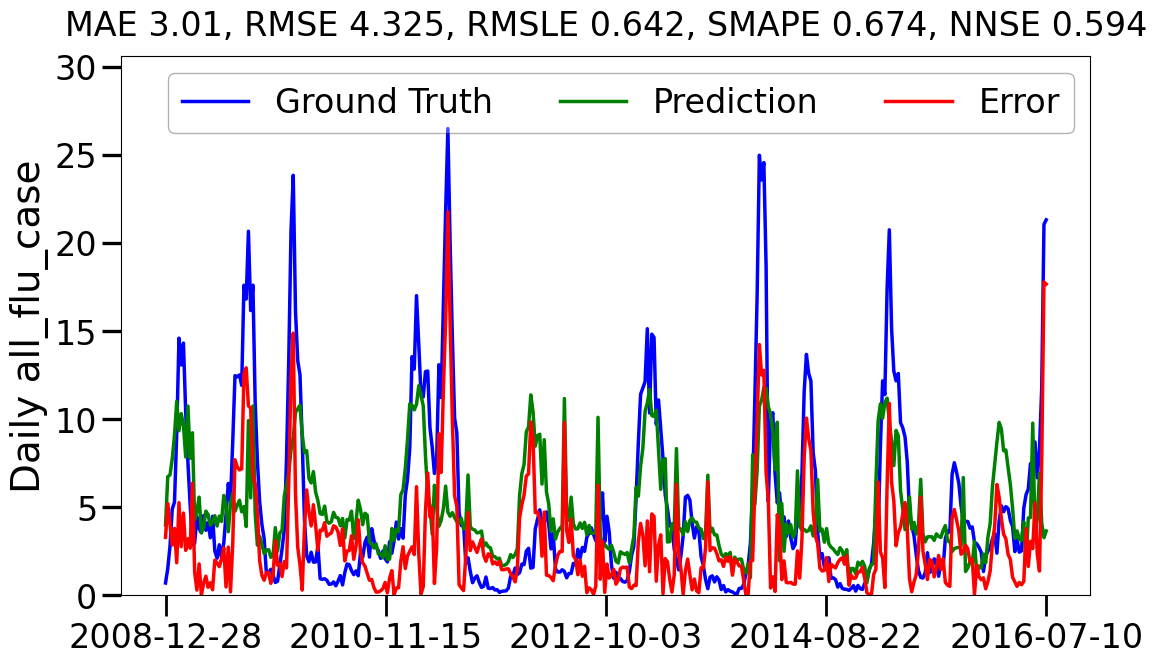

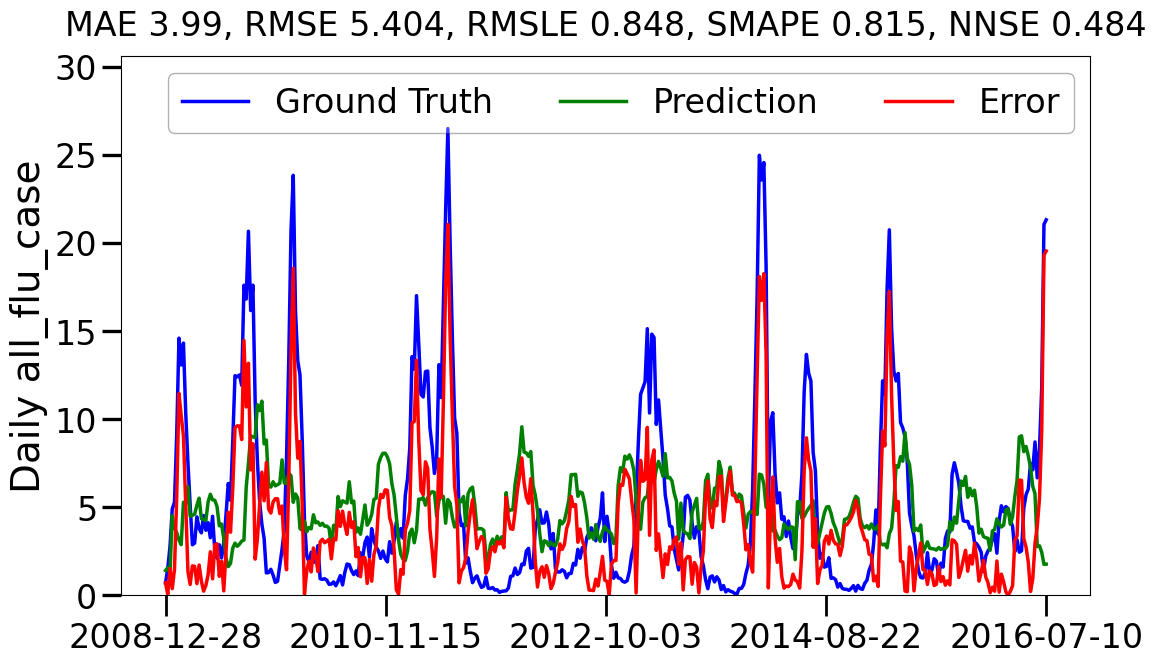

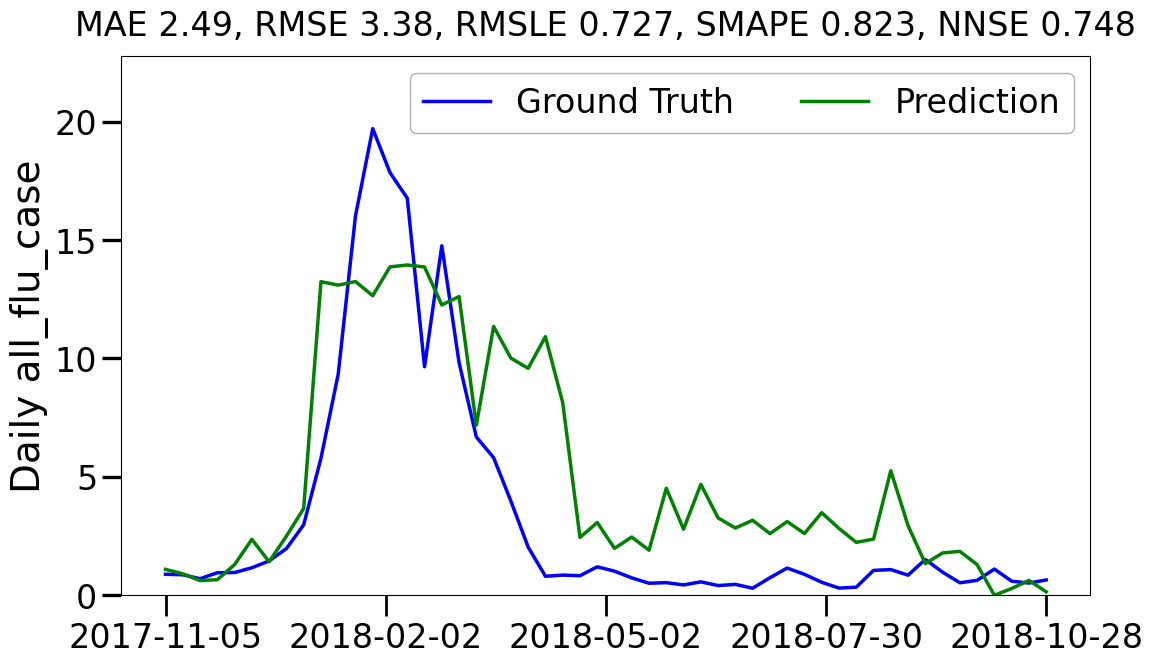

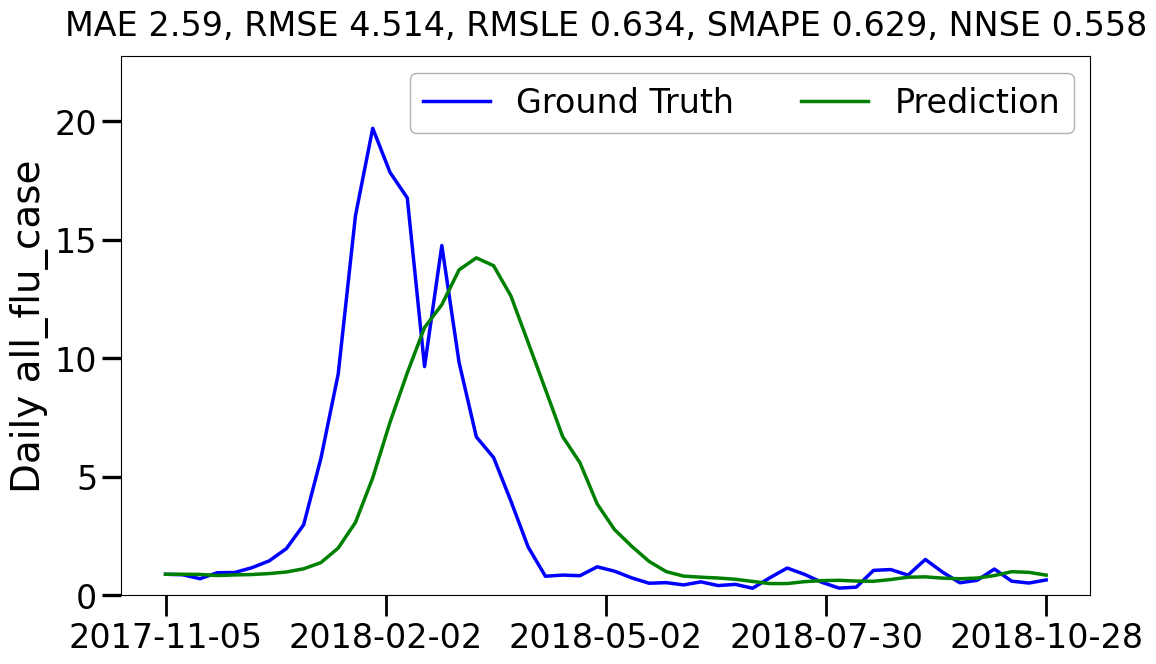

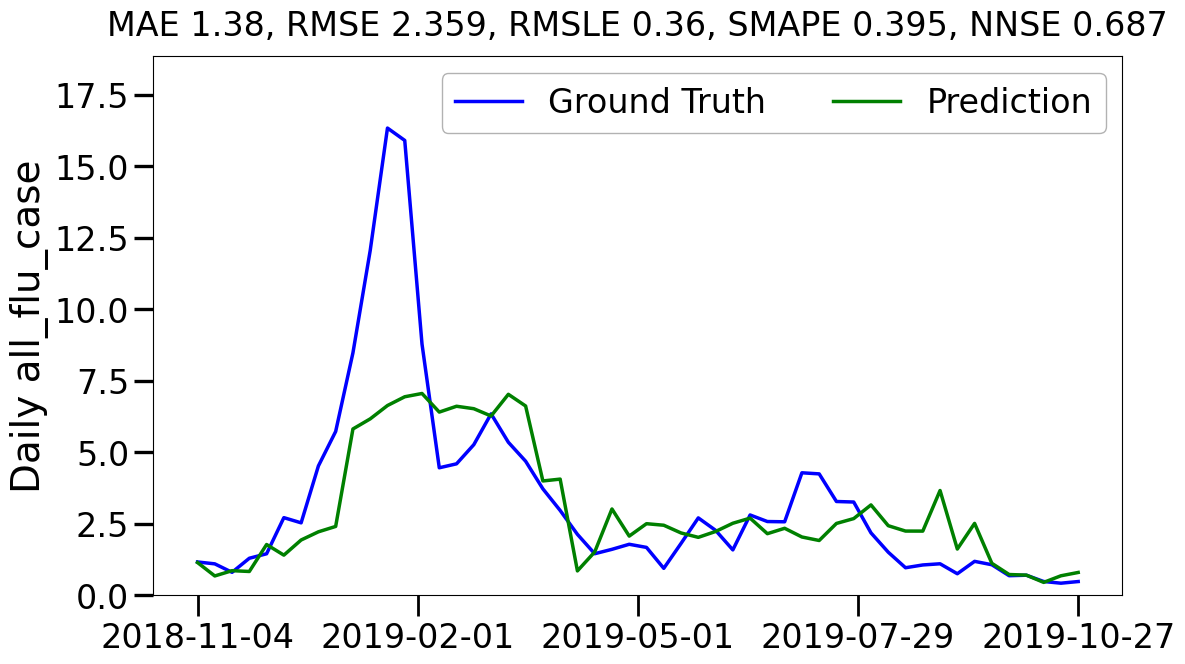

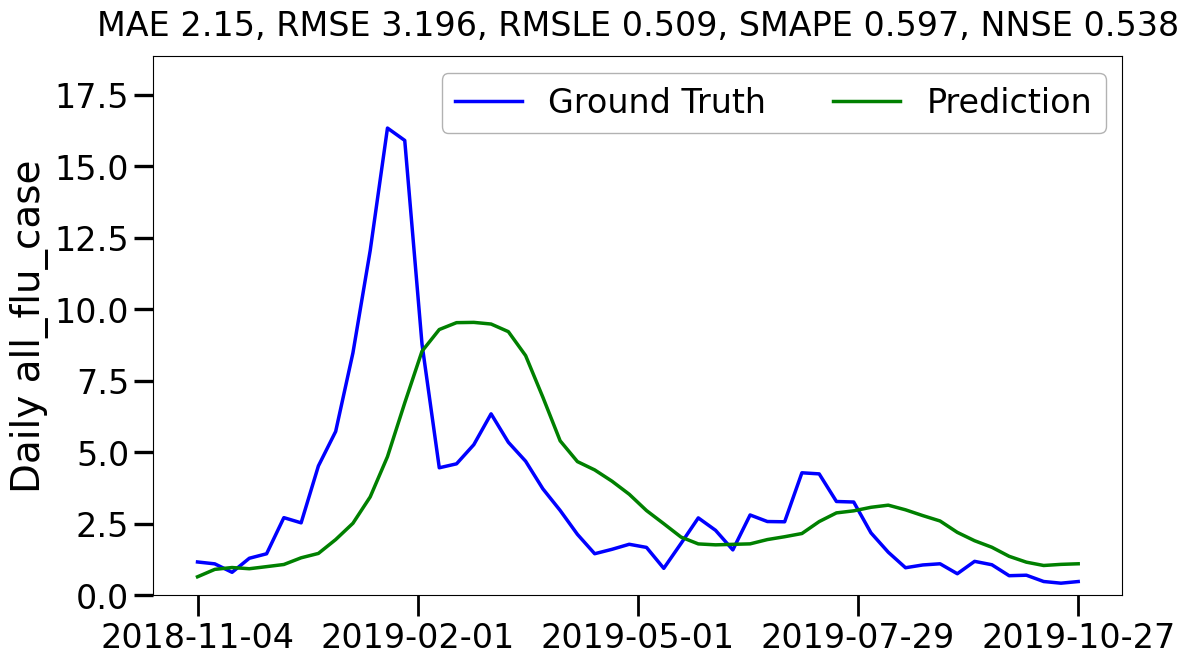

[<Figure size 1250x700 with 1 Axes>]

In [55]:
os.chdir('/Users/yanchen/Documents/git/gpce-covid-main/TFT-pytorch')
plotter.summed_plot(train_result_merged, type='Train_error', plot_error=True)
plotter.summed_plot(baseline_train_result_merged, type='Train_error_baseline', plot_error=True)
plotter.summed_plot(val_result_merged, type='Validation',plot_error=False)
plotter.summed_plot(baseline_val_result_merged, type='Validation_baseline', plot_error=False)
plotter.summed_plot(test_result_merged, type='Test',plot_error=False)
plotter.summed_plot(baseline_test_result_merged, type='Test_baseline', plot_error=False)

### Validation results

### Test results

In [56]:


resid_tft = train_result_merged['all_flu_case'].values - train_result_merged['Predicted_all_flu_case'].values
# 50% interval
lowq = pd.DataFrame(resid_tft).quantile(0.25)
higq = pd.DataFrame(resid_tft).quantile(0.75)

"""
path = f'/Users/yanchen/Documents/git/gpce-covid-main/TFT-pytorch/results/tft/tft-school-absence/lookback8-predict8-test{year}-fixstart/test_result_merged.pkl'
test_result_merged_from_read = pd.read_pickle(path)

y_test_pred = test_result_merged_from_read['Predicted_all_flu_case'].values
lowt_tft = (y_test_pred + lowq.values)
higt_tft = (y_test_pred + higq.values)

test_result_merged_from_read['pred_low'] = lowt_tft
test_result_merged_from_read['pred_high'] = higt_tft
dict_lowt_tft[year]=lowt_tft
dict_higt_tft[year] = higt_tft
dict_df_test_compare_tft[year] = test_result_merged_from_read
"""

y_test_pred = test_result_merged['Predicted_all_flu_case'].values
lowt_tft = (y_test_pred + lowq.values)
higt_tft = (y_test_pred + higq.values)

test_result_merged['pred_low'] = lowt_tft
test_result_merged['pred_high'] = higt_tft
dict_lowt_tft[year]=lowt_tft
dict_higt_tft[year] = higt_tft
dict_df_test_compare_tft[year] = test_result_merged

In [57]:
resid = baseline_train_result_merged['all_flu_case'].values - baseline_train_result_merged['Predicted_all_flu_case'].values
# 50% interval
lowq = pd.DataFrame(resid).quantile(0.25)
higq = pd.DataFrame(resid).quantile(0.75)
y_test_pred = baseline_test_result_merged['Predicted_all_flu_case'].values
lowt = (y_test_pred + lowq.values)
higt = (y_test_pred + higq.values)

baseline_test_result_merged['pred_low'] = lowt
baseline_test_result_merged['pred_high'] = higt
dict_lowt[year] = lowt
dict_higt[year]=higt
dict_df_test_compare[year]=baseline_test_result_merged

In [58]:
baseline_total_df_test_compare = pd.concat(dict_df_test_compare.values(), ignore_index=True)
tft_total_df_test_compare = pd.concat(dict_df_test_compare_tft.values(), ignore_index=True)


In [60]:


parent_dir = '/Users/yanchen/Dropbox/hksph/hksph-project/result-072024/tft'
os.chdir(parent_dir)

is_plot_total = True
sample_weight_mode = 'plain'
model_type = 'tft'

folder_name = 'absence_'+str(IS_ABSEN)+'_sample-weight-'+sample_weight_mode+'-lookback-'+str(max_encoder_length)+'-forecast-'+str(max_prediction_length)
os.makedirs(folder_name, exist_ok  = True)
path = os.path.join(parent_dir, folder_name)
os.chdir(path)

tft_total_df_test_compare.to_csv(f'{sample_weight_mode}_weight_{max_prediction_length}week_total_df_test_compare.csv')
#path = f'{sample_weight_mode}_weight_{max_prediction_length}week_total_df_test_compare.csv'
#tft_total_df_test_compare = pd.read_csv(path,index_col=0)


In [439]:
is_plot_total = True
model_type = 'baseline'
sample_weight_mode = 'plain'
os.chdir('/Users/yanchen/Dropbox/hksph/hksph-project/result-052024/baseline')
baseline_total_df_test_compare.to_csv(f'{sample_weight_mode}_weight_{max_prediction_length}week_total_df_test_compare.csv')
#path = f'{sample_weight_mode}_weight_{max_prediction_length}week_total_df_test_compare.csv'
#baseline_total_df_test_compare = pd.read_csv(path,index_col=0)

In [110]:


#parent_folder = '/Users/yanchen/Documents/git/gpce-covid-main/TFT-pytorch/results/tft/tft-noabsence-2008/'
parent_folder = '/Users/yanchen/Documents/git/gpce-covid-main/TFT-pytorch/results/tft/tft-school-absence/'
sub_folder = 'lookback8-predict8-test2014-fixstart'
path = parent_folder + sub_folder
if not os.path.exists(path):
    os.mkdir(path)
os.chdir(path)
val_result_merged.to_pickle("val_result_merged.pkl") 
test_result_merged.to_pickle("test_result_merged.pkl") 
baseline_val_result_merged.to_pickle("baseline_val_result_merged.pkl") 
baseline_test_result_merged.to_pickle("baseline_test_result_merged.pkl")
# save dictionary to person_data.pkl file
with open('best_params.pkl', 'wb') as fp:
    pickle.dump(best_params, fp)
    print('dictionary saved successfully to file')

dictionary saved successfully to file


In [172]:
#os.chdir('/Users/yanchen/Documents/git/gpce-covid-main/TFT-pytorch/results/tft/tft-school-absence/lookback8-predict8-test2017-fixstart')
with open('best_params.pkl', 'rb') as fp:
    best_params_read = pickle.load(fp)
    print('best_params dictionary')
    print(best_params_read)

best_params dictionary
{'gradient_clip_val': 0.5, 'hidden_size': 4, 'dropout': 0.2, 'hidden_continuous_size': 4, 'attention_head_size': 2, 'learning_rate': 0.01}


In [48]:


os.chdir('/Users/yanchen/Documents/git/gpce-covid-main/TFT-pytorch/results/tft/tft-school-absence/lookback8-predict8-test2013-fixstart')
test_result_merged_2013 = pd.read_pickle("test_result_merged.pkl")
baseline_test_result_merged_2013 =pd.read_pickle("baseline_test_result_merged.pkl")
show_result(test_result_merged_2013, targets)
#show_result(baseline_test_result_merged_2013, targets)

os.chdir('/Users/yanchen/Documents/git/gpce-covid-main/TFT-pytorch/results/tft/tft-school-absence/lookback8-predict8-test2014-fixstart')
test_result_merged_2014 = pd.read_pickle("test_result_merged.pkl")
baseline_test_result_merged_2014 =pd.read_pickle("baseline_test_result_merged.pkl") 
show_result(test_result_merged_2014, targets)
#show_result(baseline_test_result_merged_2014, targets)

os.chdir('/Users/yanchen/Documents/git/gpce-covid-main/TFT-pytorch/results/tft/tft-school-absence/lookback8-predict8-test2015-fixstart')
test_result_merged_2015 = pd.read_pickle("test_result_merged.pkl")
baseline_test_result_merged_2015 =pd.read_pickle("baseline_test_result_merged.pkl")
show_result(test_result_merged_2015, targets)
#show_result(baseline_test_result_merged_2015, targets)

os.chdir('/Users/yanchen/Documents/git/gpce-covid-main/TFT-pytorch/results/tft/tft-school-absence/lookback8-predict8-test2016-fixstart')
test_result_merged_2016 = pd.read_pickle("test_result_merged.pkl")
baseline_test_result_merged_2016 =pd.read_pickle("baseline_test_result_merged.pkl")
show_result(test_result_merged_2016, targets)
#show_result(baseline_test_result_merged_2016, targets)

os.chdir('/Users/yanchen/Documents/git/gpce-covid-main/TFT-pytorch/results/tft/tft-school-absence/lookback8-predict8-test2017-fixstart')
test_result_merged_2017 = pd.read_pickle("test_result_merged.pkl")
baseline_test_result_merged_2017 =pd.read_pickle("baseline_test_result_merged.pkl")
show_result(test_result_merged_2017, targets)
#show_result(baseline_test_result_merged_2017, targets)

os.chdir('/Users/yanchen/Documents/git/gpce-covid-main/TFT-pytorch/results/tft/tft-school-absence/lookback8-predict8-test2018-fixstart')
test_result_merged_2018 = pd.read_pickle("test_result_merged.pkl")
baseline_test_result_merged_2018 =pd.read_pickle("baseline_test_result_merged.pkl") 
show_result(test_result_merged_2018, targets)
#show_result(baseline_test_result_merged_2018, targets)


Target all_flu_case, MAE 2.81, RMSE 3.498, RMSLE 0.701, SMAPE 0.7556, NNSE 0.6016.

Target all_flu_case, MAE 3.148, RMSE 4.861, RMSLE 0.6182, SMAPE 0.7338, NNSE 0.6562.

Target all_flu_case, MAE 2.378, RMSE 3.231, RMSLE 0.5568, SMAPE 0.6251, NNSE 0.7101.

Target all_flu_case, MAE 4.786, RMSE 7.032, RMSLE 0.8396, SMAPE 0.7271, NNSE 0.4843.

Target all_flu_case, MAE 2.244, RMSE 3.342, RMSLE 0.6346, SMAPE 0.9118, NNSE 0.6975.

Target all_flu_case, MAE 1.288, RMSE 2.246, RMSLE 0.3638, SMAPE 0.3956, NNSE 0.7196.



In [49]:
test_result_merged_all = pd.concat((test_result_merged_2013
                                    ,test_result_merged_2014,test_result_merged_2015,test_result_merged_2016
                                    ,test_result_merged_2017,test_result_merged_2018))

baseline_test_result_merged_all = pd.concat((baseline_test_result_merged_2013,baseline_test_result_merged_2014
                                             ,baseline_test_result_merged_2015,baseline_test_result_merged_2016
                                             ,baseline_test_result_merged_2017,baseline_test_result_merged_2018))

print('target',targets)
print('----TFT-----')
show_result(test_result_merged_all, targets)
print('----Baseline-----')
show_result(baseline_test_result_merged_all, targets)

target ['all_flu_case']
----TFT-----
Target all_flu_case, MAE 2.775, RMSE 4.319, RMSLE 0.6353, SMAPE 0.6914, NNSE 0.6117.

----Baseline-----
Target all_flu_case, MAE 3.163, RMSE 4.879, RMSLE 0.6369, SMAPE 0.6515, NNSE 0.5496.



In [51]:
baseline_test_result_merged_all

,region,time_idx,Predicted_all_flu_case,all_flu_case,Date
0,HK,217,0.967840,1.305816,2012-11-04
1,HK,218,1.136828,0.989012,2012-11-11
2,HK,219,1.087556,0.959139,2012-11-18
3,HK,220,1.055452,0.787682,2012-11-25
4,HK,221,1.001898,0.746195,2012-12-02
...,...,...,...,...,...
47,HK,525,1.363812,0.685753,2018-09-30
48,HK,526,1.158900,0.702738,2018-10-07
49,HK,527,1.042639,0.482297,2018-10-14
50,HK,528,1.081931,0.423800,2018-10-21


From visualization, we can see that the TFT Model was able to capture dynamics of the validation datset

### Convergence Curve

<Axes: >

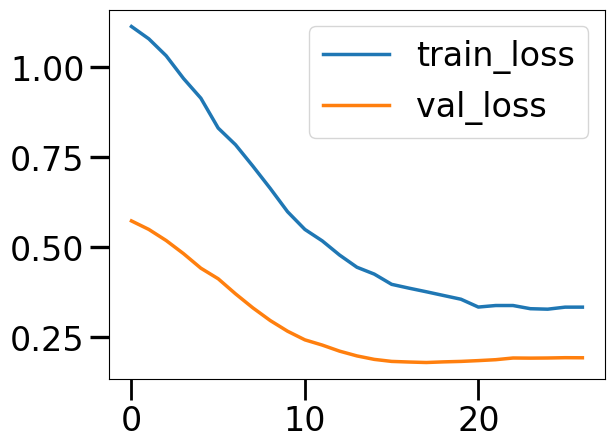

In [755]:
ls_train_loss = trainer.callbacks[2].metrics['train_loss_epoch']
ls_val_loss =trainer.callbacks[2].metrics['val_loss']
df_losses = pd.DataFrame(list(zip(ls_train_loss,ls_val_loss)),
                         columns = ['train_loss','val_loss'])
df_losses.plot()

### Variable importance

In [242]:
best_tft.decoder_variables

['year_cos',
 'year_sin',
 'month_cos',
 'month_sin',
 'week_cos',
 'week_sin',
 'absolute_humidity',
 'pressure',
 'relative_humidity',
 'solar_radiation',
 'temp_max',
 'temp_mean',
 'temp_min',
 'temp_range',
 'total_rainfall',
 'wind_speed']

In [243]:
best_tft.encoder_variables

['year_cos',
 'year_sin',
 'month_cos',
 'month_sin',
 'week_cos',
 'week_sin',
 'absolute_humidity',
 'pressure',
 'relative_humidity',
 'solar_radiation',
 'temp_max',
 'temp_mean',
 'temp_min',
 'temp_range',
 'total_rainfall',
 'wind_speed',
 'all_flu_case',
 'Adenovirus_case',
 'RSV_case',
 'b_pos_case',
 'h1_pos_case',
 'paraflu12_case',
 'paraflu34_case',
 'sh3_pos_case']

{'attention': <Figure size 640x480 with 1 Axes>,
 'static_variables': <Figure size 700x225 with 1 Axes>,
 'encoder_variables': <Figure size 700x800 with 1 Axes>,
 'decoder_variables': <Figure size 700x600 with 1 Axes>}

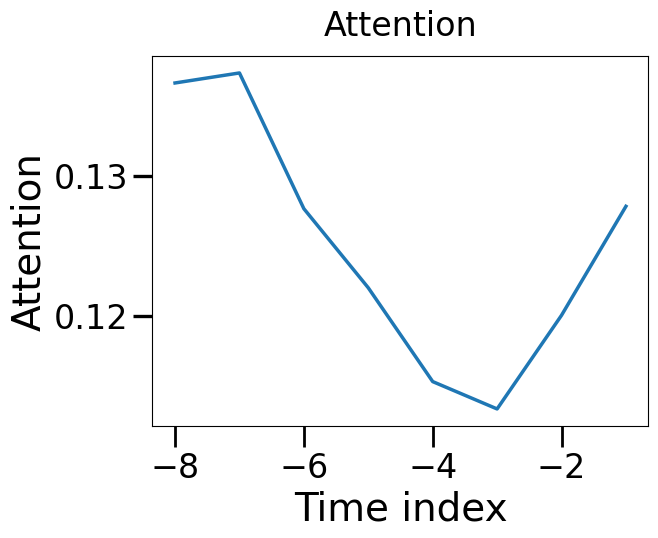

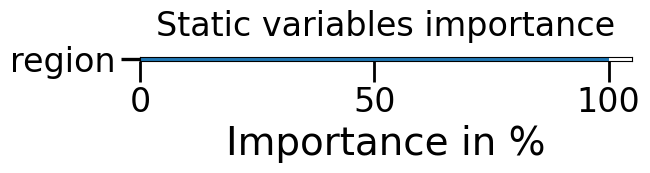

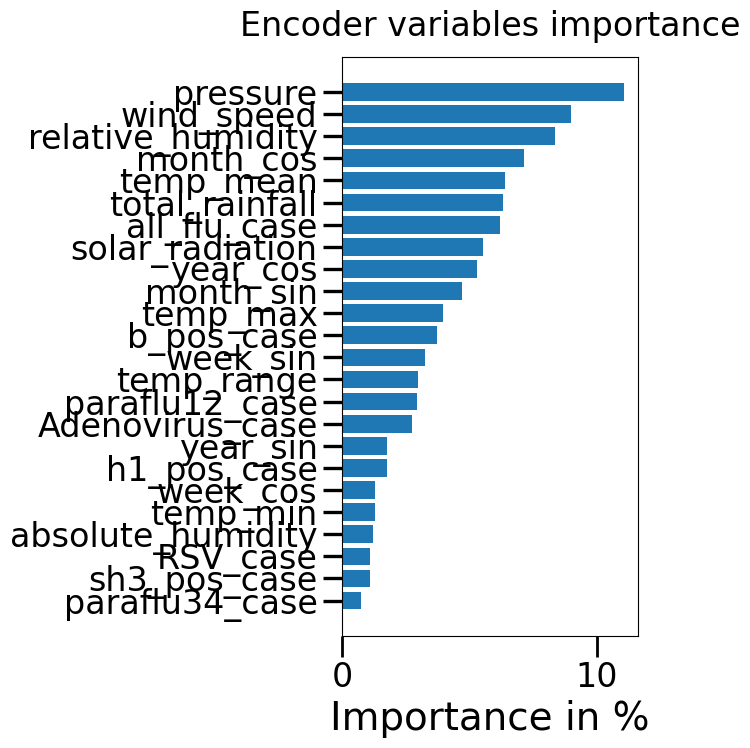

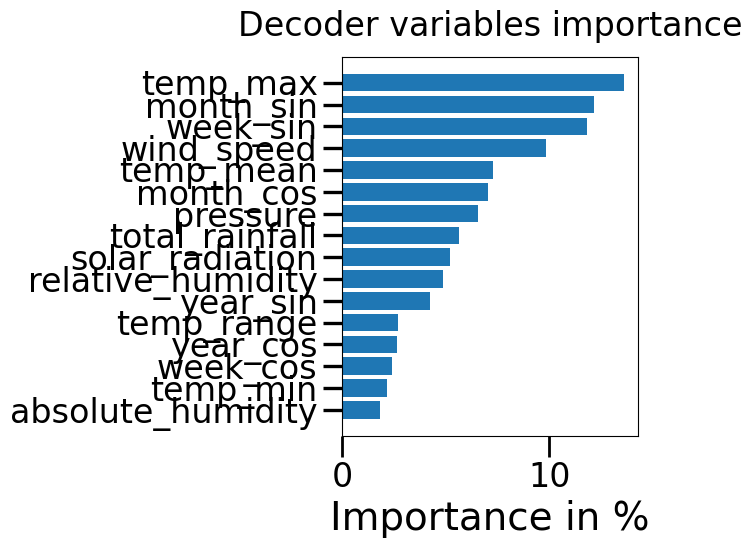

In [244]:
interpretation = best_tft.interpret_output(tft_raw_val_prediction.output, reduction="sum")
best_tft.plot_interpretation(interpretation)

In [245]:
#dict_tft_imp_enc_importance_no_abs = {}
#dict_tft_imp_dec_importance_no_abs = {}

dict_tft_imp_enc_importance_no_abs['2013'] = interpretation['encoder_variables']
dict_tft_imp_dec_importance_no_abs['2013'] = interpretation['decoder_variables']

In [218]:
os.chdir('/Users/yanchen/Documents/git/gpce-covid-main/TFT-pytorch/results/tft/tft-school-absence')

with open('dict_tft_imp_enc_importance.pkl', 'wb') as fp:
    pickle.dump(dict_tft_imp_enc_importance, fp)
    print('enc imp saved successfully to file')

with open('dict_tft_imp_dec_importance.pkl', 'wb') as fp:
    pickle.dump(dict_tft_imp_dec_importance, fp)
    print('dec saved successfully to file')

enc imp saved successfully to file
dec saved successfully to file


In [266]:
encoder_variables = ['year_cos',
 'year_sin',
 'month_cos',
 'month_sin',
 'week_cos',
 'week_sin',
 'absent_proportion',
 'absolute_humidity',
 'pressure',
 'relative_humidity',
 'solar_radiation',
 'temp_max',
 'temp_mean',
 'temp_min',
 'temp_range',
 'total_rainfall',
 'wind_speed',
 'all_flu_case',
 'Adenovirus_case',
 'RSV_case',
 'b_pos_case',
 'h1_pos_case',
 'paraflu12_case',
 'paraflu34_case',
 'sh3_pos_case']

COLS = encoder_variables


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


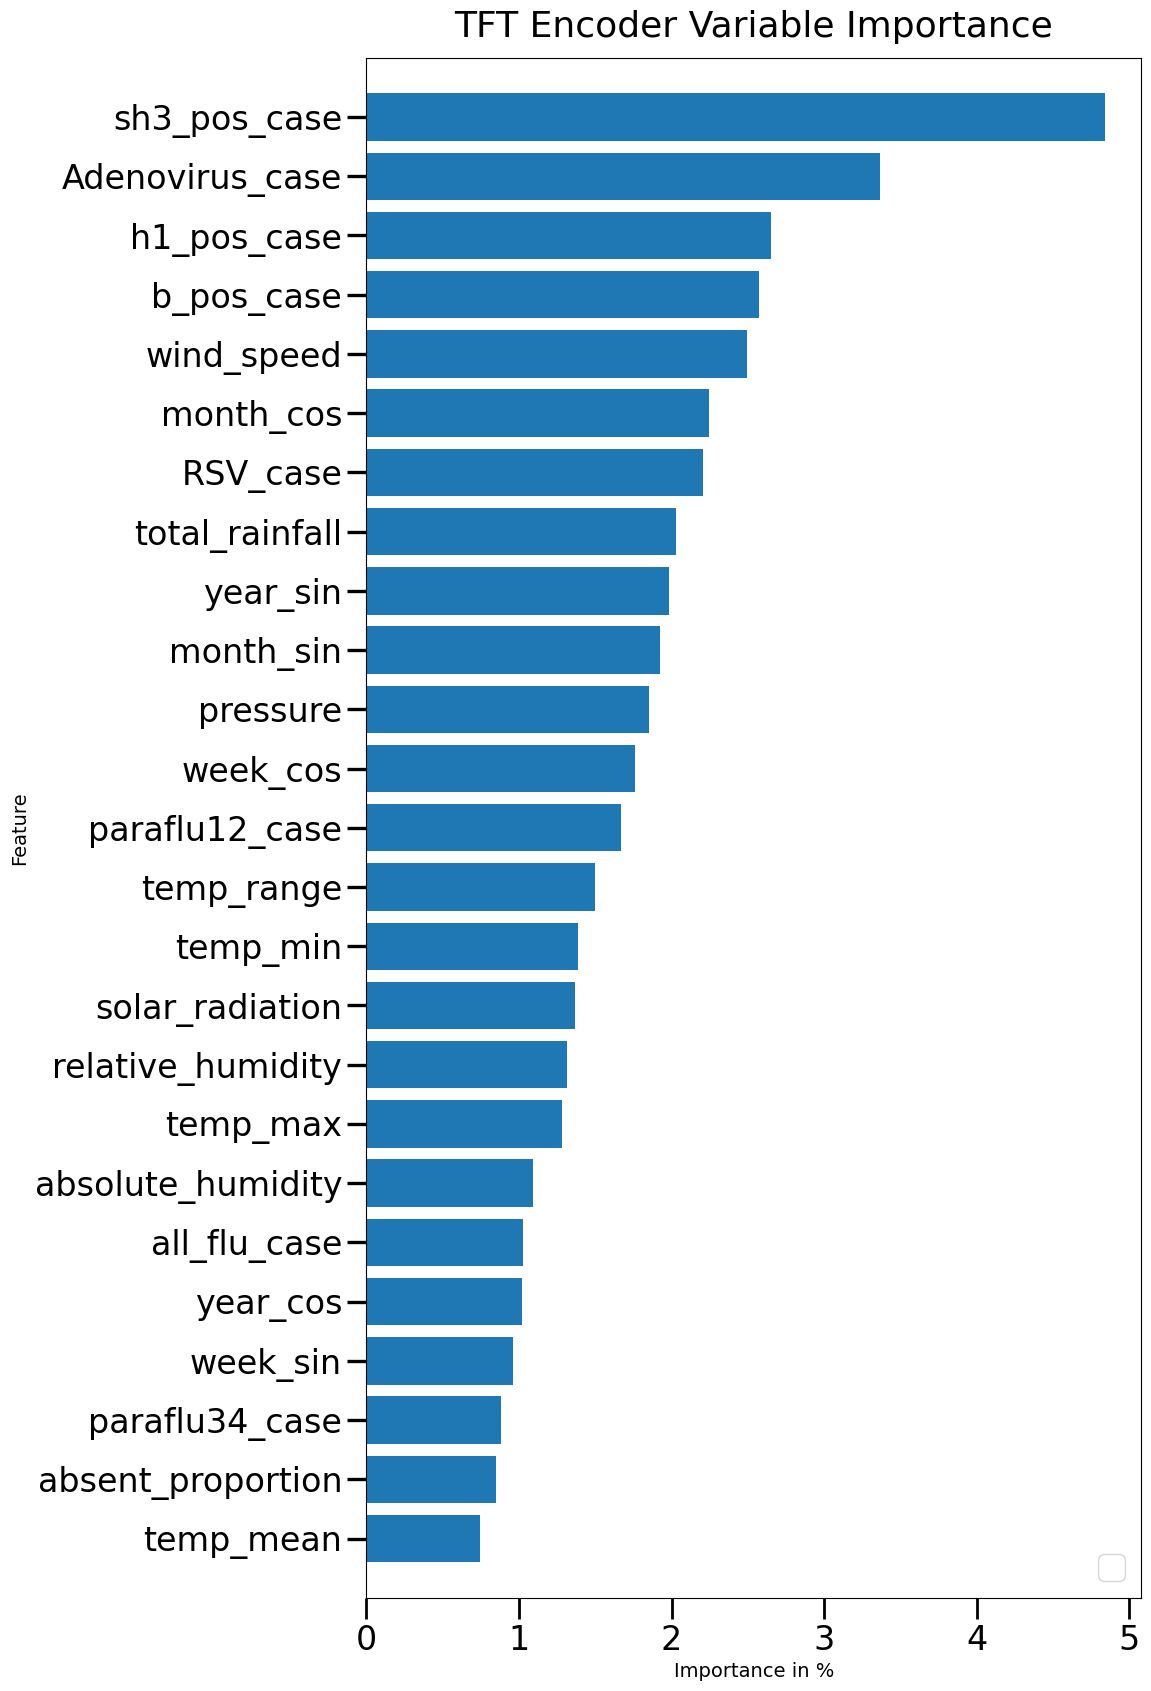

In [268]:
ls_imp_df = [pd.DataFrame({'feat':encoder_variables,'imp':dict_tft_imp_enc_importance[k]}) for k in dict_tft_imp_enc_importance]
ls_imp_arr = [df['imp'].values for df in ls_imp_df]

avg2_importances = np.mean(ls_imp_arr, axis=0)
baseline_mae = avg2_importances[0]
if True:
      print()
      df = pd.DataFrame({'feature':encoder_variables,'imp':avg2_importances})
      df = df.sort_values('imp')
      plt.figure(figsize=(10,20))
      plt.barh(np.arange(len(COLS)),df.imp)
      plt.yticks(np.arange(len(COLS)),df.feature.values)
      plt.title('TFT Encoder Variable Importance',size=26)
      plt.ylim((-1,len(COLS)))
      #plt.plot([baseline_mae,baseline_mae],[-1,len(COLS)+1], '--', color='orange',
      #               label=f'Baseline OOF\nMAE={baseline_mae:.3f}')
      plt.xlabel(f'Importance in %',size=14)
      plt.ylabel('Feature',size=14)
      plt.legend()
      plt.show()


In [271]:
decoder_variables = ['year_cos',
 'year_sin',
 'month_cos',
 'month_sin',
 'week_cos',
 'week_sin',
 'absent_proportion',
 'absolute_humidity',
 'pressure',
 'relative_humidity',
 'solar_radiation',
 'temp_max',
 'temp_mean',
 'temp_min',
 'temp_range',
 'total_rainfall',
 'wind_speed']
COLS = decoder_variables


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


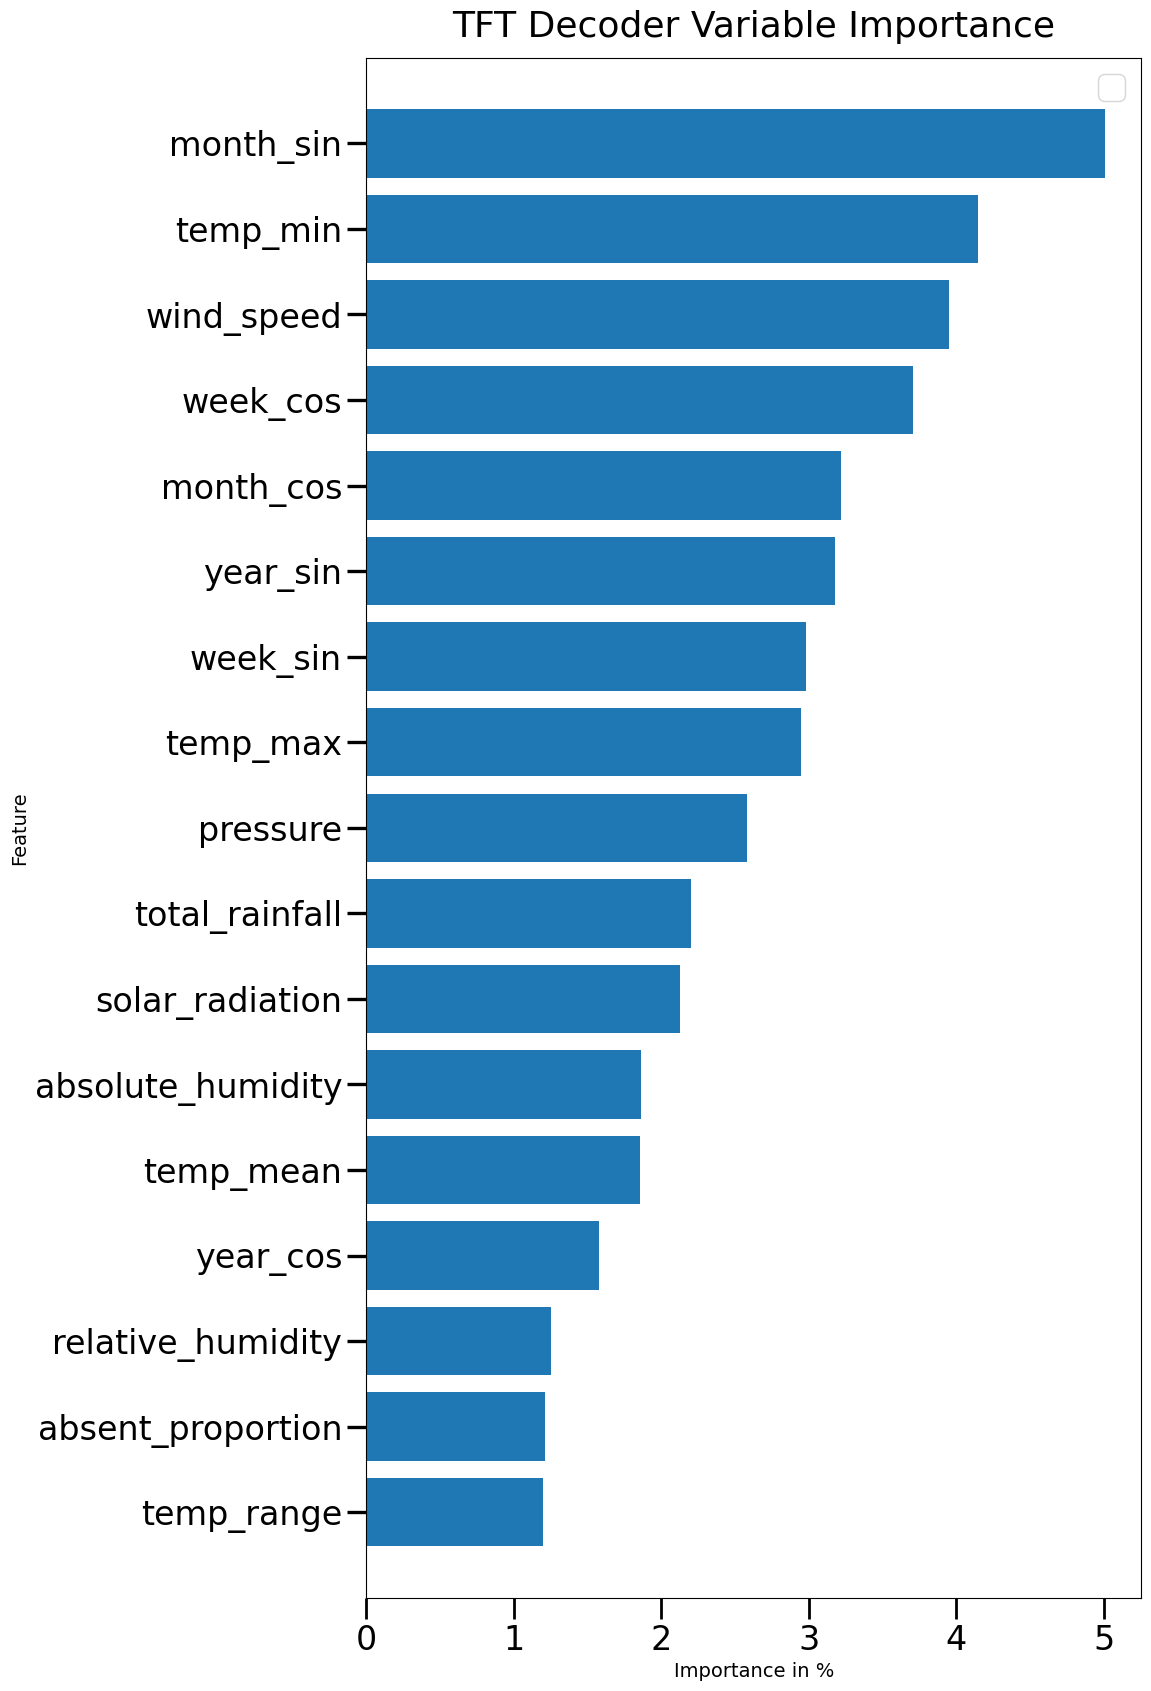

In [272]:
ls_imp_df = [pd.DataFrame({'feat':decoder_variables,'imp':dict_tft_imp_dec_importance[k]}) for k in dict_tft_imp_dec_importance]
ls_imp_arr = [df['imp'].values for df in ls_imp_df]

avg2_importances = np.mean(ls_imp_arr, axis=0)
baseline_mae = avg2_importances[0]
if True:
      print()
      df = pd.DataFrame({'feature':decoder_variables,'imp':avg2_importances})
      df = df.sort_values('imp')
      plt.figure(figsize=(10,20))
      plt.barh(np.arange(len(COLS)),df.imp)
      plt.yticks(np.arange(len(COLS)),df.feature.values)
      plt.title('TFT Decoder Variable Importance',size=26)
      plt.ylim((-1,len(COLS)))
      plt.xlabel(f'Importance in %',size=14)
      plt.ylabel('Feature',size=14)
      plt.legend()
      plt.show()


Hyperparameter tuning

In [ ]:
#PYTORCH_ENABLE_MPS_FALLBACK=1

from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters

# create study
study = optimize_hyperparameters(
    train_dataloader,
    val_dataloader,
    model_path="optuna_test",
    n_trials=200, #Number of hyperparameter combination trials to run. Defaults to 100.
    max_epochs=100, #Maximum number of epochs to run training. Defaults to 20.
    #gradient_clip_val_range=(0.01, 1.0),
    gradient_clip_val_range=(0.01, 0.5),
    #hidden_size_range=(8, 128),
    #hidden_continuous_size_range=(8, 128),
    hidden_size_range=(2, 10),
    hidden_continuous_size_range=(2, 10),
    attention_head_size_range=(1, 4),
    #learning_rate_range=(0.001, 0.1),
    learning_rate_range=(0.01, 0.1),
    dropout_range=(0.1, 0.3),
    trainer_kwargs=dict(limit_train_batches=30,accelerator="cpu"), #limit_train_batches limits the number of batches fetched from the DataLoader for each epoch. The epoch ends once this limit is reached.
    reduce_on_plateau_patience=4,
    use_learning_rate_finder=False,  # use Optuna to find ideal learning rate or use in-built learning rate finder,
    loss=MultiLoss([RMSE(reduction='mean') for _ in targets]) # RMSE(reduction='sqrt-mean')
)

# save study results - also we can resume tuning at a later point in time
with open("test_study.pkl", "wb") as fout:
    pickle.dump(study, fout)

# show best hyperparameters
print(study.best_trial.params)



[I 2026-02-14 12:15:57,749] A new study created in memory with name: no-name-392c0082-e45b-4c0f-9441-6b879154367e
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=100` reached.
[I 2026-02-14 12:16:28,197] Trial 0 finished with value: 1.0904103517532349 and parameters: {'gradient_clip_val': 0.4780451703372482, 'hidden_size': 4, 'dropout': 0.136543145659681, 'hidden_continuous_size': 3, 'attention_head_size': 2, 'learning_rate': 0.06157906998895074}. Best is trial 0 with value: 1.0904103517532349.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=100` reached.
[I 2026-02-14 12:17:03,421] Trial 1 finished with value: 0.25565195083618164 and parameters: {'gradient_clip_val': 0.21196993054402, 'hidden_size': 7, 'dropout'